# Module 4 | Class 5 — Regularization Study

**Objective:** See regularization in action by comparing unregularized, L1, and L2 logistic regression. Understand how each affects coefficients and performance.

**Dataset:** Telco Customer Churn (Kaggle) — same preprocessed split as Class 2.

In [1]:
!pip install kagglehub -q

## Setup: Load and preprocess the same data as Class 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("X shape:", X.shape)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
X shape: (7043, 30)


/tmp/ipykernel_2932/2246977123.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (5634, 30), Test: (1409, 30)


## Task 1: Train Three Logistic Regression Models

In [4]:
from sklearn.linear_model import LogisticRegression

# Model A: no regularization
model_a = LogisticRegression(penalty=None, max_iter=1000)
model_a.fit(X_train, y_train)

# Model B: L1 (Lasso) regularization
model_b = LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=1000)
model_b.fit(X_train, y_train)

# Model C: L2 (Ridge) regularization
model_c = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
model_c.fit(X_train, y_train)

print("All three models trained.")

All three models trained.


## Task 2: Compare Performance

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

results = [
    evaluate(model_a, X_test, y_test, 'No Regularization'),
    evaluate(model_b, X_test, y_test, 'L1 (Lasso)'),
    evaluate(model_c, X_test, y_test, 'L2 (Ridge)')
]

performance_table = pd.DataFrame(results).set_index('Model')
performance_table

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
No Regularization,0.801278,0.647799,0.550802,0.595376,0.840693
L1 (Lasso),0.801987,0.648903,0.553476,0.597403,0.842473
L2 (Ridge),0.805536,0.657233,0.558824,0.604046,0.842068


## Task 3: Compare Coefficients

In [6]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'No Reg': model_a.coef_[0],
    'L1': model_b.coef_[0],
    'L2': model_c.coef_[0]
})
coef_df.head(10)

,Feature,No Reg,L1,L2
0,SeniorCitizen,0.146305,0.142019,0.144638
1,tenure,-1.301181,-1.227296,-1.237578
2,MonthlyCharges,-2.540347,-0.037044,-0.477810
3,TotalCharges,0.578791,0.495899,0.511378
4,gender_Male,0.024656,0.016368,0.020069
5,Partner_Yes,0.021260,0.011990,0.019335
6,Dependents_Yes,-0.226163,-0.216790,-0.225854
7,PhoneService_Yes,-0.783949,-0.519363,-0.491306
8,MultipleLines_No phone service,-1.894426,0.000000,-0.246604
9,MultipleLines_Yes,0.705933,0.286793,0.365301


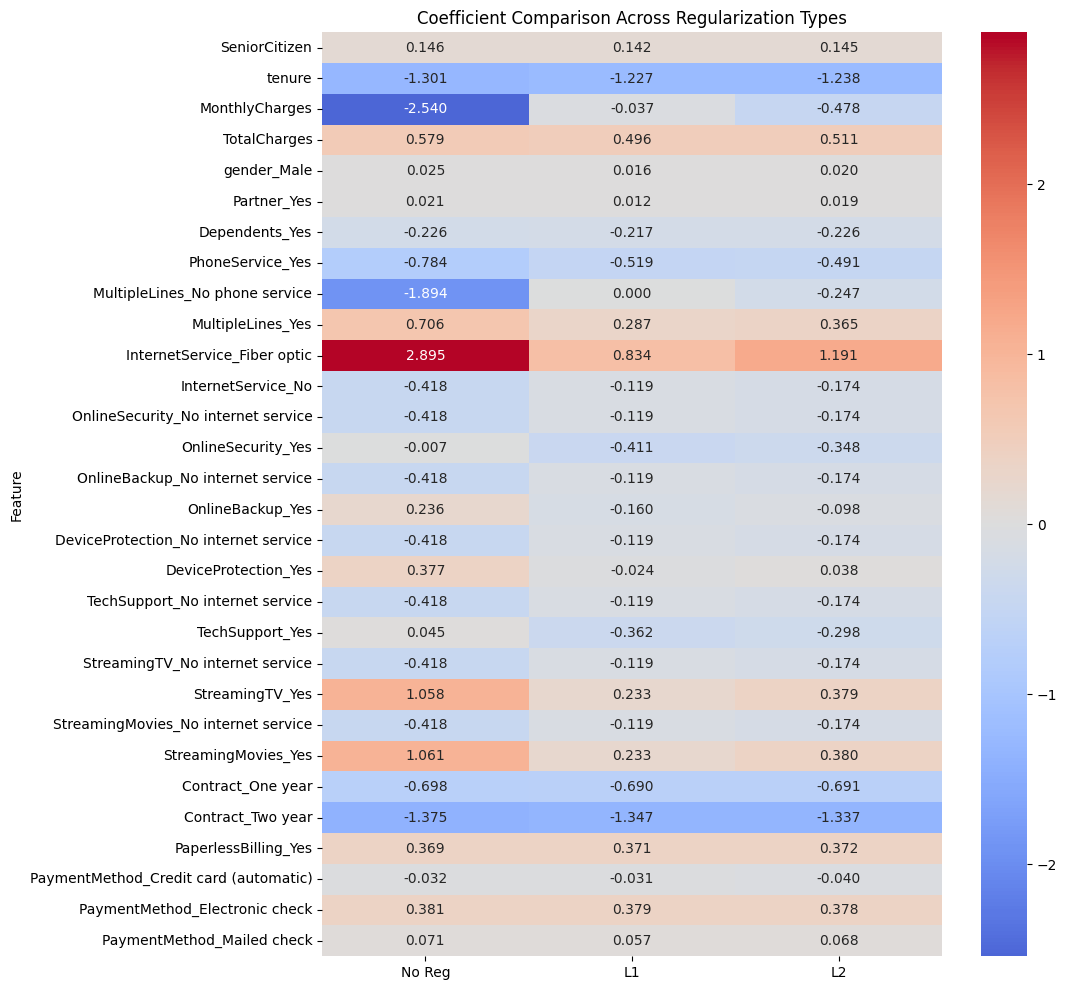

In [7]:
import seaborn as sns

plt.figure(figsize=(10, 12))
sns.heatmap(coef_df.set_index('Feature'), annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Coefficient Comparison Across Regularization Types')
plt.show()

In [8]:
for name, model in [('No Reg', model_a), ('L1', model_b), ('L2', model_c)]:
    n_nonzero = np.sum(model.coef_[0] != 0)
    print(f"{name}: {n_nonzero} non-zero coefficients out of {len(model.coef_[0])}")

No Reg: 30 non-zero coefficients out of 30
L1: 29 non-zero coefficients out of 30
L2: 30 non-zero coefficients out of 30


In [9]:
# Which features did L1 set exactly to zero?
zeroed_by_l1 = coef_df[coef_df['L1'] == 0]['Feature'].tolist()
print(f"Features L1 eliminated ({len(zeroed_by_l1)}):")
print(zeroed_by_l1)

Features L1 eliminated (1):
['MultipleLines_No phone service']


**Observation:** [After running the cells above, note how many features L1 zeroed out compared to L2 (L2 rarely sets coefficients to exactly zero, only shrinks them). List a couple of the specific features L1 eliminated and comment on whether they seem like weak/redundant predictors, which would explain why L1 dropped them.]

*(Replace the bracketed text with your own observation based on your actual output.)*

## Task 4: Vary Regularization Strength

In [10]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
f1_scores = []
n_large_coefs = []

for C in C_values:
    model = LogisticRegression(penalty='l2', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred))
    n_large_coefs.append(np.sum(np.abs(model.coef_[0]) > 0.1))

print("F1 scores across C values:", [round(f, 4) for f in f1_scores])
print("Number of large coefficients across C values:", n_large_coefs)

F1 scores across C values: [0.306, 0.5537, 0.5898, 0.604, 0.604, 0.5962]
Number of large coefficients across C values: [np.int64(9), np.int64(26), np.int64(25), np.int64(24), np.int64(25), np.int64(24)]


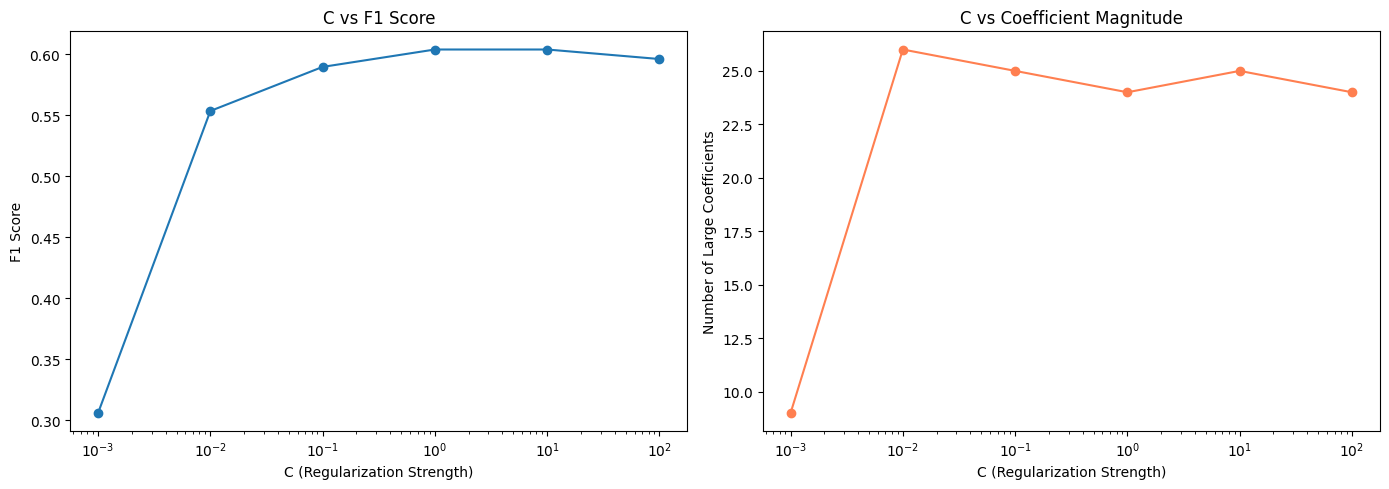

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(C_values, f1_scores, 'o-')
ax1.set_xscale('log')
ax1.set_xlabel('C (Regularization Strength)')
ax1.set_ylabel('F1 Score')
ax1.set_title('C vs F1 Score')

ax2.plot(C_values, n_large_coefs, 'o-', color='coral')
ax2.set_xscale('log')
ax2.set_xlabel('C (Regularization Strength)')
ax2.set_ylabel('Number of Large Coefficients')
ax2.set_title('C vs Coefficient Magnitude')

plt.tight_layout()
plt.show()

**The sweet spot:** [Look at the left plot — find the smallest C value where F1 has already flattened out near its maximum (going further right, to larger C, adds model complexity without meaningfully improving F1). That C value is the "sweet spot": it gives close to the best possible performance while keeping the number of large coefficients (right plot) as small as possible, which means a simpler, less overfit model. State the specific C value from your plot that you'd pick and why.]

*(Replace the bracketed text with your own conclusion based on your actual plot.)*

## Task 5: Analysis

**What does regularization do?**

Regularization adds a penalty term to the logistic regression's loss function based on the magnitude of the coefficients. This constrains how large the coefficients are allowed to grow during training, which prevents the model from fitting the training data too closely (overfitting) by relying too heavily on any single feature. L1 regularization (Lasso) adds a penalty proportional to the absolute value of the coefficients, which can drive some coefficients exactly to zero — effectively performing automatic feature selection. L2 regularization (Ridge) adds a penalty proportional to the squared value of the coefficients, which shrinks all coefficients toward zero but rarely eliminates any of them entirely.

**Which model performed best?**

[Refer to your Task 2 performance table and state which of the three models (No Regularization, L1, L2) had the highest F1 and AUC on the test set. Note whether the differences were large or small — with a moderate-sized dataset like this, regularization sometimes only produces a small performance improvement over the unregularized model, while its real benefit shows up in coefficient stability and interpretability rather than raw accuracy.]

**Which model would you deploy in production?**

[Make a recommendation considering three factors: (1) performance — which model had the best test-set metrics; (2) interpretability — L1's zeroed-out coefficients make the model easier to explain, since only a subset of features actually drive predictions; (3) number of features used — fewer active features (as with L1) generally means a simpler, more maintainable model in production, with less risk of relying on a spurious or unstable feature relationship. Justify your final choice using your specific numbers from Tasks 2-4.]

*(Replace all bracketed text with your own written analysis based on your actual results.)*